## **RISK MEASUREMENT PROJECT**

<u>GROUP 3:</u>
- NDEYE ARAME MBENGUE
- EDOARDO NICOLETTI
- GABRIEL ANZALONE

## Loading the Data

In [272]:
# We import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [273]:
# file_path = "/Users/edoardonicoletti/Desktop/EDHEC M2/Risk_Measurament/842 Risk Measurement Hallerbach - data for group assignment.xlsx" # remodify here
file_path = "842 Risk Measurement Hallerbach - data for group assignment (1).xlsx"
df = pd.read_excel(file_path, sheet_name=None,skiprows= 9)
df = df['daily_data']
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

In [274]:
#from google.colab import drive # modify here if needed
#drive.mount('/content/drive')

In [275]:
df.head()

,Mkt,Tsies,CorpIG,CorpHY,AR,Oil
date,,,,,,
1994-12-30,1.000000,1.000000,1.000000,1.000000,1.000000,17.77
1995-01-03,0.997600,0.997267,0.997864,1.000572,1.008810,17.45
1995-01-04,1.001092,1.001366,1.001542,1.002199,1.015014,17.56
1995-01-05,1.000791,0.997262,0.999229,1.004223,1.014720,17.76
1995-01-06,1.002793,0.997943,1.000934,1.002199,1.013431,17.69


##  Inspecting the data

In [276]:
# If we first count the number of N/A per asset class & the min/max return/price
print(df.isna().sum())
print(df.describe().loc[['min', 'max']])

Mkt       0
Tsies     0
CorpIG    0
CorpHY    0
AR        0
Oil       0
dtype: int64
           Mkt     Tsies    CorpIG    CorpHY        AR     Oil
min   0.997600  0.996580  0.997864  1.000000  0.852990  -36.98
max  23.293702  1.764456  5.320129  7.636756  9.859741  145.31


<b><u>Comment:</b></u>
- No N/A in the data.
- Min and max values show disparities between the asset classes, but they stay logical.
- Except for Oil, where we have a negative oil price somewhere.

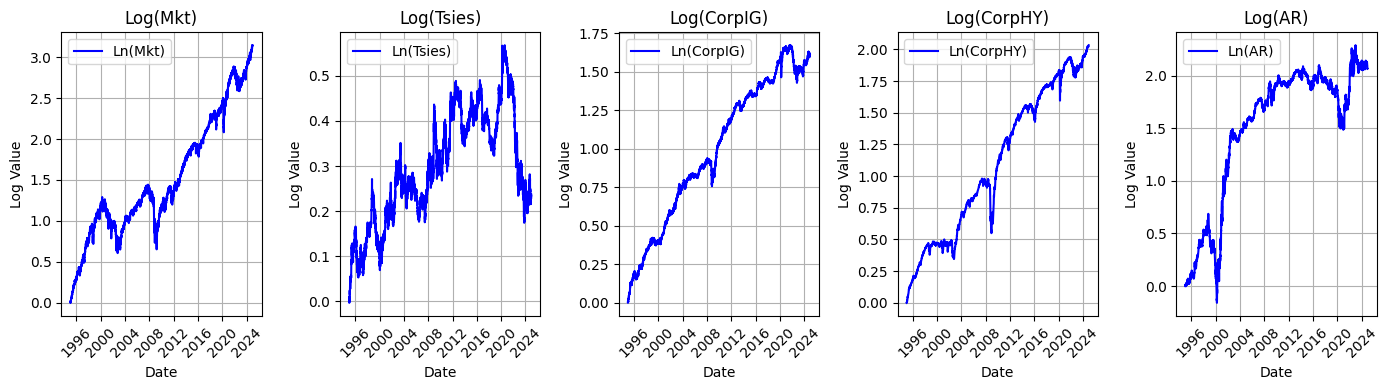

In [277]:
# Plotting log(index) for Mkt, Tsies, CorpIG, CorpHY & AR first:
num_columns_first = 5
fig, axes = plt.subplots(1, num_columns_first, figsize=(14, 4))
for i, column in enumerate(df.columns[:num_columns_first]):
    log_index = np.log(df[column])
    axes[i].plot(df.index, log_index, label=f'Ln({column})', color='blue')
    axes[i].set_title(f'Log({column})')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Log Value')
    axes[i].legend()
    axes[i].grid(True)
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

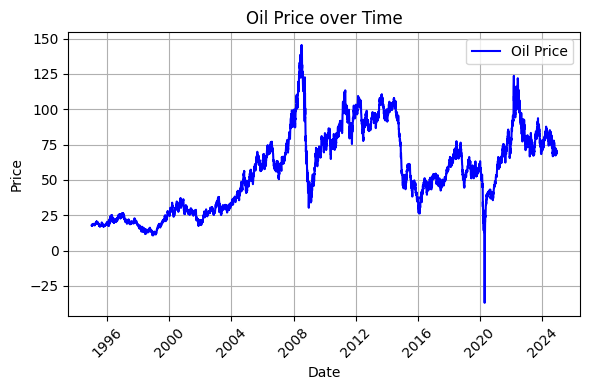

In [278]:
# If we plot the Oil price over time
plt.figure(figsize=(6, 4))
plt.plot(df.index, df['Oil'], label='Oil Price', color='blue')
plt.title('Oil Price over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<b><u>Comment:</b></u>
- We have a negative oil price in 2020.
- We will forward fill it with the previous value, if the latter is positive -> use previous non-missing level value(kind of winsorizing)
- Otherwise would bias all return statistics

In [279]:
df['Oil'].idxmin()

Timestamp('2020-04-20 00:00:00')

In [280]:
min_oil_date = '2020-04-20'
df.loc[min_oil_date, 'Oil'] = df['Oil'].shift(1).loc[min_oil_date]

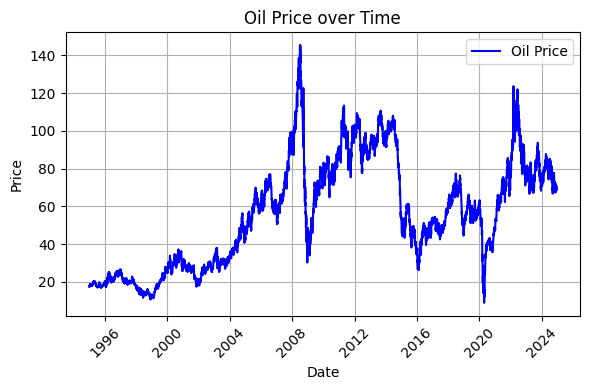

In [281]:
plt.figure(figsize=(6, 4))
plt.plot(df.index, df['Oil'], label='Oil Price', color='blue')
plt.title('Oil Price over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## <u>RQ1–volatility:
### What are the ex-ante volatilities of the augmented & default portfolios on Wednesday 11-Dec-2024 close and how does this compare against the course of these ex-ante volatilities over time ?

#### 1-EWMA

<u>Vol horizon ?</u>
- Daily: we have daily data & are focused on a specific date here.
- Consistent with the PM’s weekly trading frequency.

<u>Model ?</u>
- Basically 3 choices here: EW, GARCH or EWMA
- Pb with EW: no information decay & in our work we would prefer to assign more weight to recent obs -> let the weight of past observations decrease smoothly over time

- Pb with GARCH here: quite cumbersome in this multiasset context: requires 3 parameter estimates per security volatility

- So what we did: first used EWMA vol (λ = 0.94) (Retains exponentially declining weights & information decay + no ghost effect
ignore mean-reversion & ignore LT variance level + EWMA works very well in practice) & then GARCH(1,1) and did a comparison of the 2.

In [282]:
returns = np.log(df / df.shift(1)).dropna()

In [283]:
returns.head(3)

,Mkt,Tsies,CorpIG,CorpHY,AR,Oil
date,,,,,,
1995-01-03,-0.002403,-0.002736,-0.002138,0.000572,0.008771,-0.018172
1995-01-04,0.003494,0.004101,0.003679,0.001625,0.006131,0.006284
1995-01-05,-0.000300,-0.004107,-0.002313,0.002017,-0.000290,0.011325


In [284]:
w_default = np.array([0.50, 0.30, 0.05, 0.00, 0.10, 0.05])
w_augmented = np.array([0.40, 0.40, 0.00, 0.05, 0.15, 0.00])

In [285]:
# Calculating returns on both the default and the augmented
ret_default = returns @ w_default
ret_augmented = returns @ w_augmented

In [286]:
returns = returns.rename(columns={0: 'Return'})
ret_default = pd.DataFrame(ret_default, columns=['Return'])
ret_augmented = pd.DataFrame(ret_augmented, columns=['Return'])

In [287]:
ret_default.head(3)

,Return
date,
1995-01-03,-0.002161
1995-01-04,0.004089
1995-01-05,-0.000961


In [288]:
ret_augmented.head(3)

,Return
date,
1995-01-03,-0.000711
1995-01-04,0.004039
1995-01-05,-0.001706


In [289]:
def ewma_volatility(returns, lambda_=0.94): #Decay factor we can choose
    squared_returns = returns**2#Need to square to calculate the variance
    ewma_var = [squared_returns.iloc[0,0]]

    for i in range(1, len(squared_returns)):  # Iterate using index -> change here as I renamed the column
        r2 = squared_returns.iloc[i, 0]
        ewma_prev = ewma_var[-1]
        ewma_new = lambda_ * ewma_prev + (1 - lambda_) * r2
        ewma_var.append(ewma_new)

    ewma_vol = pd.Series(np.sqrt(ewma_var), index=squared_returns.index[0:len(ewma_var)])
    return ewma_vol

In [290]:
vol_default=ewma_volatility(ret_default) #Vol for the default portfolio
vol_augmented=ewma_volatility(ret_augmented) #Vol for the augmented portfolio

In [291]:
decision_day = pd.to_datetime('2024-12-11')

In [292]:
# Extract the volatilities for 11-Dec-2024
vol_date = '2024-12-11'
vol_default_11dec = vol_default.loc[vol_date]
vol_augmented_11dec = vol_augmented.loc[vol_date]

# Print the results
print(f"Default portfolio volatility on {vol_date}: {vol_default_11dec:.4%}")
print(f"Augmented portfolio volatility on {vol_date}: {vol_augmented_11dec:.4%}")

Default portfolio volatility on 2024-12-11: 0.3441%
Augmented portfolio volatility on 2024-12-11: 0.2724%


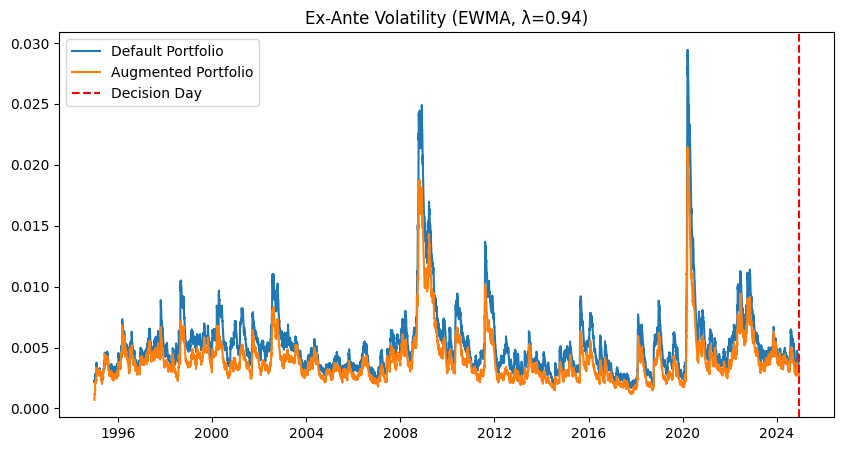

In [293]:
plt.figure(figsize=(10, 5))
plt.plot(vol_default, label='Default Portfolio')
plt.plot(vol_augmented, label='Augmented Portfolio')
plt.axvline(x=decision_day, color='red', linestyle='--', label='Decision Day')
plt.title("Ex-Ante Volatility (EWMA, λ=0.94)")
plt.legend()
plt.show()

- We estimated the ex-ante volatility of the default and augmented portfolios as of 11-Dec-2024 using the EWMA model with λ = 0.94, a commonly used parameter that emphasizes recent data while smoothing short-term noise.

- Portfolio-level returns were computed by applying the respective asset weights to daily log returns. The resulting EWMA volatility time series shows similar dynamics for both portfolios, with notable spikes during major crises (e.g., 2008, 2020).

- However, the augmented portfolio consistently exhibits lower volatility, reflecting its more defensive allocation (more Treasuries, no Oil, reduced Equities).

<u>Estimation Approach ?</u>
- Computed daily log returns from price indices and constructed portfolio returns using the specified asset weights.
- EWMA volatility was estimated using the full historical window from 1994 to 2024, providing a long-term out-of-sample view.

<u>Evaluation Criteria ?</u>
- As a first step, we visually assessed the volatility dynamics of both portfolios and compared values on the decision date (11-Dec-2024).
- Ex-Ante Volatility Over Time:the EWMA model captures historical spikes (e.g., 2008, 2020), showing meaningful differences between portfolios, particularly during periods of stress.

#### 2-GARCH

- EWMA: more weight on recent returns + works well for short-term volatility estimation.
- GARCH: useful when volatility tends to persist over time, especially in more turbulent market conditions / Should better explain high volatility clustering

In [294]:
pip install arch

In [295]:
from arch import arch_model

In [296]:
model_default = arch_model(ret_default, vol='Garch', p=1, q=1) # fit it both for default & optimized ptf
garch_default_fit = model_default.fit()

model_augmented = arch_model(ret_augmented, vol='Garch', p=1, q=1)
garch_augmented_fit = model_augmented.fit()

Iteration:      1,   Func. Count:      5,   Neg. LLF: -29363.48475002579
Inequality constraints incompatible    (Exit mode 4)
            Current function value: -29363.484766844747
            Iterations: 1
            Function evaluations: 5
            Gradient evaluations: 1
Iteration:      1,   Func. Count:      5,   Neg. LLF: -31350.953373394703
Inequality constraints incompatible    (Exit mode 4)
            Current function value: -31350.953385354052
            Iterations: 1
            Function evaluations: 5
            Gradient evaluations: 1


/usr/local/lib/python3.11/dist-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 3.615e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/usr/local/lib/python3.11/dist-packages/arch/univariate/base.py:768: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
/usr/local/lib/python3.11/dist-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 2.082e-05. Parameter
estimation work better when this value is between 1 and 1000. The recomme

In [297]:
# GARCH conditional vol estimates
vol_default_garch = garch_default_fit.conditional_volatility
vol_augmented_garch = garch_augmented_fit.conditional_volatility

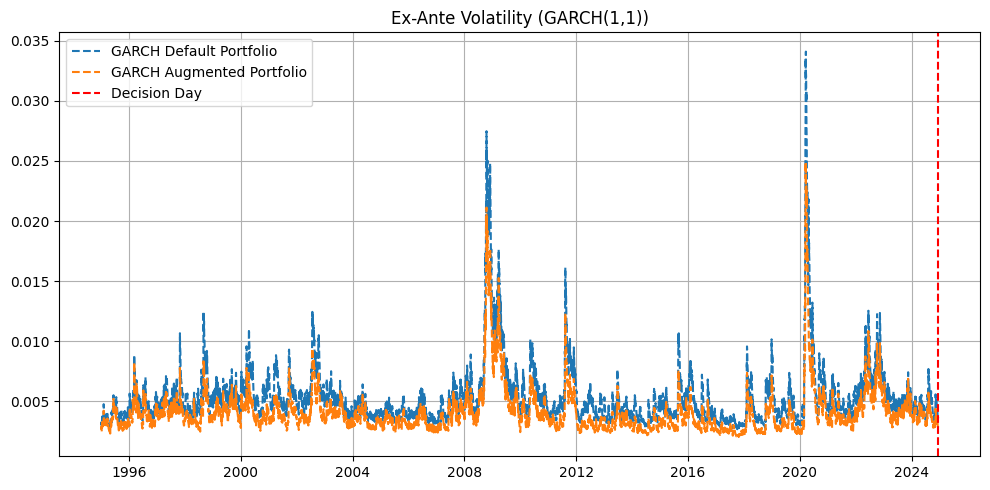

In [298]:
# Plotting GARCH vols
plt.figure(figsize=(10, 5))
plt.plot(vol_default_garch, label='GARCH Default Portfolio', linestyle='--')
plt.plot(vol_augmented_garch, label='GARCH Augmented Portfolio', linestyle='--')
plt.axvline(x=decision_day, color='red', linestyle='--', label='Decision Day')
plt.title("Ex-Ante Volatility (GARCH(1,1))")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

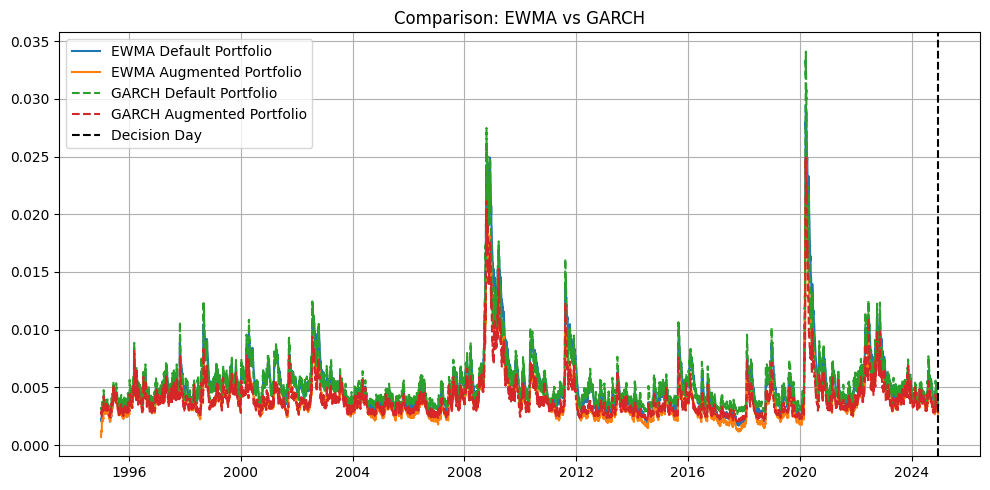

In [299]:
# Plotting everything (less visual)
plt.figure(figsize=(10, 5))
plt.plot(vol_default, label='EWMA Default Portfolio')
plt.plot(vol_augmented, label='EWMA Augmented Portfolio')
plt.plot(vol_default_garch, label='GARCH Default Portfolio', linestyle='--')
plt.plot(vol_augmented_garch, label='GARCH Augmented Portfolio', linestyle='--')
plt.axvline(x=decision_day, color='black', linestyle='--', label='Decision Day')
plt.title("Comparison: EWMA vs GARCH")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [300]:
# On decision day (vol_date = '2024-12-11')
vol_default_11dec_garch = vol_default_garch.loc[vol_date]
vol_augmented_11dec_garch = vol_augmented_garch.loc[vol_date]

print(f"Default ptf vol with GARCH on {vol_date}: {vol_default_11dec_garch:.4%}")
print(f"Augmented ptf vol with GARCH on {vol_date}: {vol_augmented_11dec_garch:.4%}")

Default ptf vol with GARCH on 2024-12-11: 0.3595%
Augmented ptf vol with GARCH on 2024-12-11: 0.2941%


- Both are a bit higher than default & augmented vol with EWMA.

#### 3-Comparison of the 2 models

- One way: select the smallest RMSE between the 2 models and real/historical vol

In [301]:
from sklearn.metrics import mean_squared_error

In [302]:
# If we compute the historical data with a window of 1 yr (252 days)
window = 252
vol_default_real = ret_default.rolling(window).std()
vol_augmented_real = ret_augmented.rolling(window).std()
vol_default_real = vol_default_real.dropna()
vol_augmented_real = vol_augmented_real.dropna()
print(vol_default_real.head())
print(vol_augmented_real.head())

              Return
date                
1995-12-29  0.003215
1996-01-02  0.003213
1996-01-03  0.003207
1996-01-04  0.003225
1996-01-05  0.003227
              Return
date                
1995-12-29  0.002912
1996-01-02  0.002911
1996-01-03  0.002905
1996-01-04  0.002917
1996-01-05  0.002921


In [303]:
vol_default_garch = vol_default_garch.loc[vol_default_real.index]
vol_augmented_garch = vol_augmented_garch.loc[vol_augmented_real.index]
vol_default_ewma = vol_default.loc[vol_default_real.index]
vol_augmented_ewma = vol_augmented.loc[vol_augmented_real.index]

rmse_default_ewma = np.sqrt(mean_squared_error(vol_default_real, vol_default_ewma))
rmse_default_garch = np.sqrt(mean_squared_error(vol_default_real, vol_default_garch))

rmse_augmented_ewma = np.sqrt(mean_squared_error(vol_augmented_real, vol_augmented_ewma))
rmse_augmented_garch = np.sqrt(mean_squared_error(vol_augmented_real, vol_augmented_garch))

print(f"RMSE Default ptf (EWMA vs Histo Vol): {rmse_default_ewma}")
print(f"RMSE Default ptf (GARCH vs Histo Vol): {rmse_default_garch}")
print(f"RMSE Augmented ptf (EWMA vs Histo Vol): {rmse_augmented_ewma}")
print(f"RMSE Augmented ptf (GARCH vs Histo Vol): {rmse_augmented_garch}")

RMSE Default ptf (EWMA vs Histo Vol): 0.0024737688740957397
RMSE Default ptf (GARCH vs Histo Vol): 0.002523864793145687
RMSE Augmented ptf (EWMA vs Histo Vol): 0.001818234499764831
RMSE Augmented ptf (GARCH vs Histo Vol): 0.0018584366927945754


- Smaller RMSE over the period for EWMA (both for default & augmented ptf)
- We would therefore continue with this model...

## <u>RQ 2 – downside risk :
### What are the ex-ante VaRs of the augmented & default portfolios on Wednesday 11-Dec-2024 close and how does this compare against the course of these ex-ante VaRs over time ?

#### 1-Parametric VaR

- Parametric VaR assumes normality and uses EWMA volatility (λ = 0.94) to capture recent changes in market risk.
- Does not require any rolling window computations for every single data point.
- So more useful for ptf exposed to more short-term fluctuations
- Works well when vol is smooth and when we don't have extreme spikes/clusters of vol.

In [304]:
# So first we consider the regulatory 1-day 95% VaR
z_95 = -1.645

# Calculate parametric VaR for both portfolios
var_default_param = z_95 * vol_default
var_augmented_param = z_95 * vol_augmented

# Extract the VaR value for 11-Dec-2024
var_default_11dec = var_default_param.loc['2024-12-11']
var_augmented_11dec = var_augmented_param.loc['2024-12-11']

# Display results
print(f"Parametric 1-day 95% VaR on 11-Dec-2024:")
print(f"  - Default Portfolio:   {var_default_11dec:.4%}")
print(f"  - Augmented Portfolio: {var_augmented_11dec:.4%}")

Parametric 1-day 95% VaR on 11-Dec-2024:
  - Default Portfolio:   -0.5661%
  - Augmented Portfolio: -0.4482%


#### 2-Historical VaR

- Non-parametric and based on the 5th percentile of a 250-day rolling window of actual returns.
- Makes no assumptions about the distribution of returns
- Can handle better non-linear and fat-tailed distributions (often observed in financial markets during periods of extreme vol).
- Reflects real mkt conditions.
- Purely based on historical data.

In [305]:
# Rolling window size (250 trading days ≈ 1 year)
window = 250
quantile = 0.05

# Calculate non-parametric (historical) VaR using rolling 5th percentile
var_default_hist = ret_default.rolling(window).quantile(quantile)
var_augmented_hist = ret_augmented.rolling(window).quantile(quantile)

# Extract values for 11-Dec-2024
var_default_hist_11dec = var_default_hist.loc['2024-12-11'].iloc[0] # Access the scalar value using .iloc[0]
var_augmented_hist_11dec = var_augmented_hist.loc['2024-12-11'].iloc[0] # Access the scalar value using .iloc[0]

# Display results
print(f"Non-Parametric (Historical) 1-day 95% VaR on 11-Dec-2024:")
print(f"  - Default Portfolio:   {var_default_hist_11dec:.4%}")
print(f"  - Augmented Portfolio: {var_augmented_hist_11dec:.4%}")

Non-Parametric (Historical) 1-day 95% VaR on 11-Dec-2024:
  - Default Portfolio:   -0.6678%
  - Augmented Portfolio: -0.5532%


In [306]:
# Align lengths by dropping NaNs
var_default_combined = pd.DataFrame({
    'Parametric': var_default_param,
    'Historical': var_default_hist['Return'] # Extract the 'Return' column as a Series
}).dropna()

var_augmented_combined = pd.DataFrame({
    'Parametric': var_augmented_param,
    'Historical': var_augmented_hist['Return'] # Extract the 'Return' column as a Series
}).dropna()

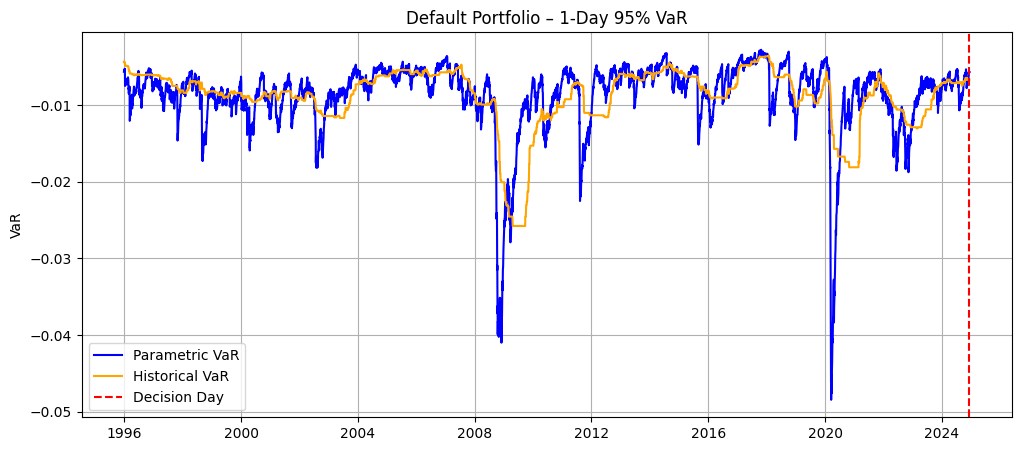

In [307]:
# Plot Default Portfolio VaR
plt.figure(figsize=(12, 5))
plt.plot(var_default_combined['Parametric'], label='Parametric VaR', color='blue')
plt.plot(var_default_combined['Historical'], label='Historical VaR', color='orange')
plt.axvline(pd.to_datetime('2024-12-11'), color='red', linestyle='--', label='Decision Day')
plt.title('Default Portfolio – 1-Day 95% VaR')
plt.ylabel('VaR')
plt.legend()
plt.grid(True)
plt.show()

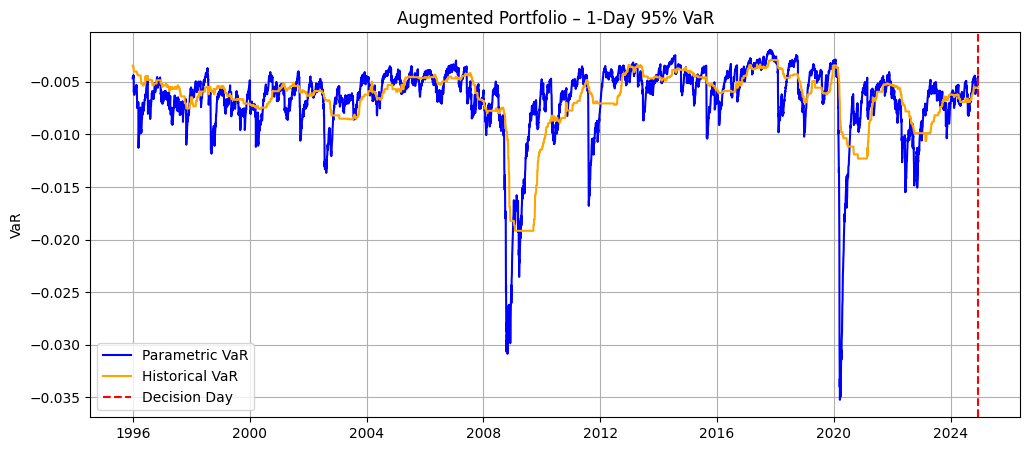

In [308]:
# Plot Augmented Portfolio VaR
plt.figure(figsize=(12, 5))
plt.plot(var_augmented_combined['Parametric'], label='Parametric VaR', color='blue')
plt.plot(var_augmented_combined['Historical'], label='Historical VaR', color='orange')
plt.axvline(pd.to_datetime('2024-12-11'), color='red', linestyle='--', label='Decision Day')
plt.title('Augmented Portfolio – 1-Day 95% VaR')
plt.ylabel('VaR')
plt.legend()
plt.grid(True)
plt.show()

<b><u>Comments:</b></u>
- On 11-Dec-2024, both models indicate that the augmented portfolio carries lower downside risk than the default portfolio, both its parametric and historical VaR estimates are less negative than those of the default portfolio on 11-Dec-2024. This aligns with its more defensive allocation. Over time, the augmented portfolio consistently shows lower VaR estimates across both methods.
- For both default & augmented ptf, seems like parametric VaR  is more reactive to the recent changes in vol. Shows also higher peaks during high vol period than historical VaR (in 2008 for instance or during Covid) -> because EWMA puts more weight on recent fluctuations.
- Historical VaR reacts way slowly to new vol informations, and it kind of smoothes the vol peaks during crisis (good example in 2008).

## <u>RQ 3 – risk decomposition :
### What are the ex-ante risk decompositions of the augmented & default portfolios on Wednesday 11-Dec-2024 close and how does this compare against the course of these decompositions over time ? ?

#### 1-252 day classic rolling window

- We first computed the risk contrib of each asset class over time with a 1 year rolling window

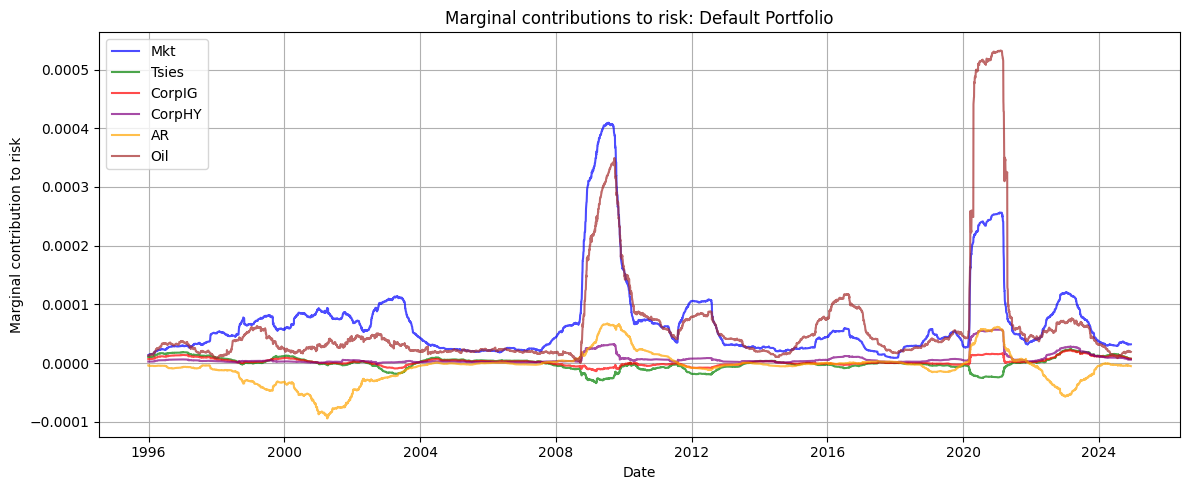

In [309]:
window = 252

returns_default = ret_default
returns_augmented = ret_augmented
marginal_contrib_default_all = []

# Marginal contrib to risk being cov.W
for i in range(window, len(df)):
    cov_matrix_window = returns.iloc[i-window:i].cov()

    marginal_contrib_default = np.dot(cov_matrix_window, w_default)
    marginal_contrib_default_all.append(marginal_contrib_default)

marginal_contrib_default_df = pd.DataFrame(marginal_contrib_default_all,
                                            columns=df.columns[0:len(w_default)],
                                            index=df.index[window:])

colors1 = ['blue', 'green', 'red', 'purple', 'orange', 'brown']
fig, axes = plt.subplots(1, 1, figsize=(12, 5))

for i, col in enumerate(marginal_contrib_default_df.columns):
    axes.plot(marginal_contrib_default_df.index, marginal_contrib_default_df[col],
              label=f'{col}', alpha=0.7, color=colors1[i])
axes.set_xlabel('Date')
axes.set_ylabel('Marginal contribution to risk')
axes.set_title('Marginal contributions to risk: Default Portfolio')
axes.legend(loc='upper left')
axes.grid(True)
plt.tight_layout()
plt.show()

<b><u>Comments:</b></u>
- We observe that in the major crisis (2008 & COVID), mkt was the biggest contributor to risk (and it was throughout the whole period by the way)
- Except in 2020 (the period when we saw oil price extremely volatile, and even going negative when we preprocessed data)
- We also see that AR acts as a risk hedge, as it has a negative risk contrib most of the time

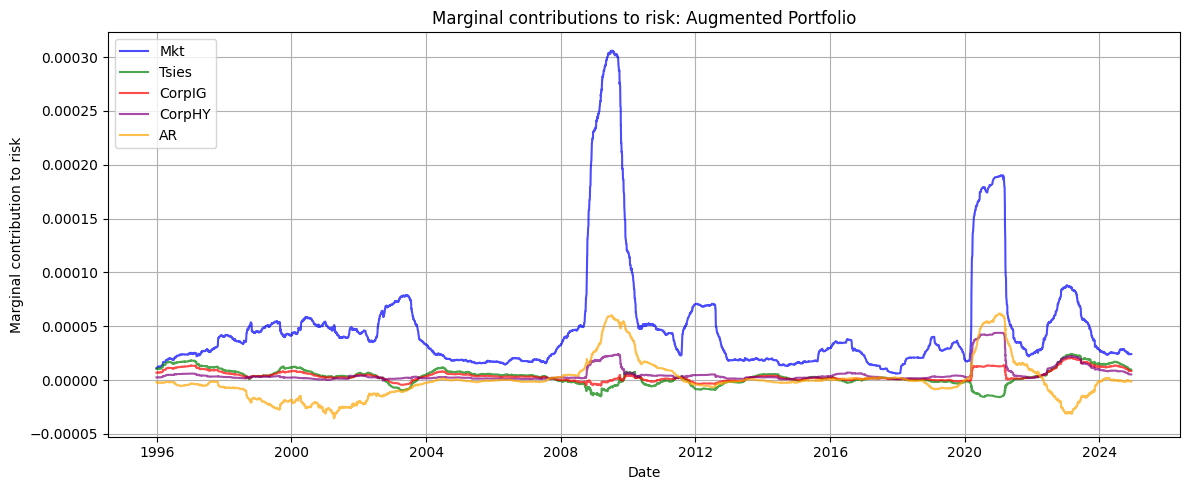

In [310]:
# For optimized ptf
# Here I had to remove the oil column otherwise I kept an oil exposure (becau
returns_default = ret_default
returns_augmented = ret_augmented
marginal_contrib_augmented_no_oil_all = []

w_augmented_no_oil = np.array([0.40, 0.40, 0.00, 0.05, 0.15])  # we exclude the oil weight/returns

for i in range(window, len(df)):
    returns_no_oil = returns.iloc[i-window:i, :5] # Selecting the first 5 asset classes only
    cov_matrix_window = returns_no_oil.cov()

    marginal_contrib_augmented_no_oil = np.dot(cov_matrix_window, w_augmented_no_oil)
    marginal_contrib_augmented_no_oil_all.append(marginal_contrib_augmented_no_oil)

marginal_contrib_augmented_no_oil_df = pd.DataFrame(marginal_contrib_augmented_no_oil_all,
                                                     columns=df.columns[0:len(w_augmented_no_oil)],
                                                     index=df.index[window:])

colors = ['blue', 'green', 'red', 'purple', 'orange']
fig, axes = plt.subplots(1, 1, figsize=(12, 5))

for i, col in enumerate(marginal_contrib_augmented_no_oil_df.columns):
    axes.plot(marginal_contrib_augmented_no_oil_df.index, marginal_contrib_augmented_no_oil_df[col],
              label=f'{col}', alpha=0.7, color=colors[i])

axes.set_xlabel('Date')
axes.set_ylabel('Marginal contribution to risk')
axes.set_title('Marginal contributions to risk: Augmented Portfolio')
axes.legend(loc='upper left')
axes.grid(True)
plt.tight_layout()
plt.show()

<b><u>Comment:</b></u>
- Mkt still is th biggest risk contributor
- And same hedge for AR

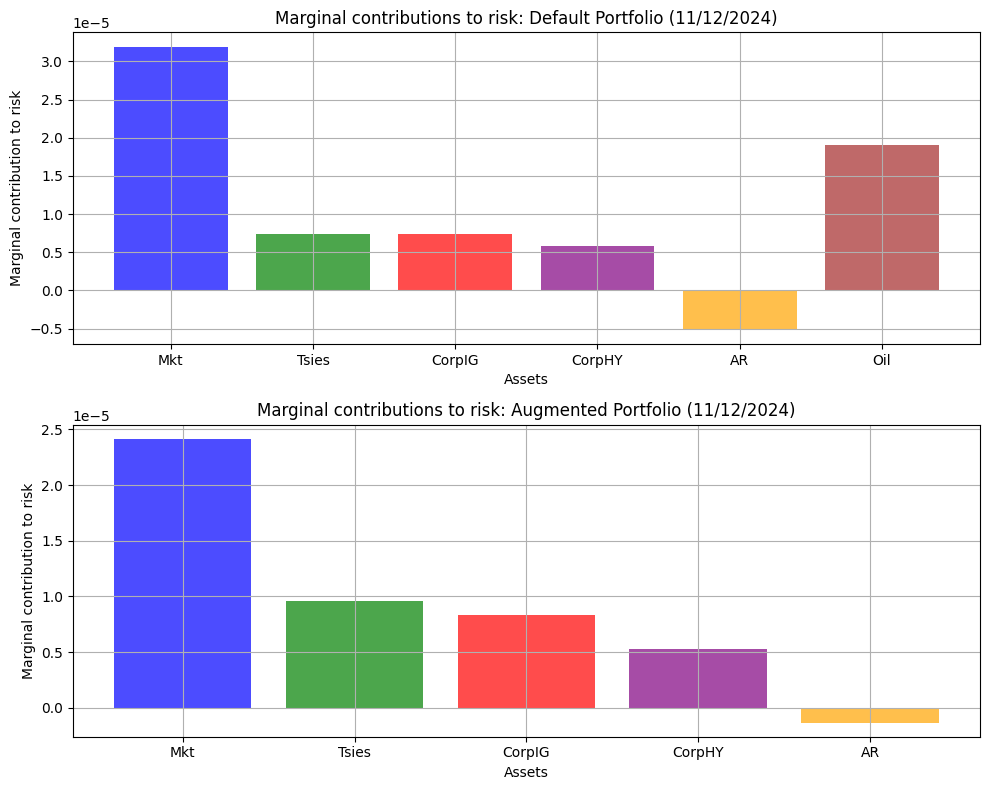

In [311]:
# And only for 2024-12-11
date_target = pd.to_datetime('2024-12-11')
marginal_contrib_default_11dec = marginal_contrib_default_df.loc[date_target]
marginal_contrib_augmented_11dec = marginal_contrib_augmented_no_oil_df.loc[date_target]

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
axes[0].bar(marginal_contrib_default_11dec.index, marginal_contrib_default_11dec,
            color=colors1[:len(marginal_contrib_default_11dec)], alpha=0.7)
axes[0].set_xlabel('Assets')
axes[0].set_ylabel('Marginal contribution to risk')
axes[0].set_title('Marginal contributions to risk: Default Portfolio (11/12/2024)')
axes[0].grid(True)

axes[1].bar(marginal_contrib_augmented_11dec.index, marginal_contrib_augmented_11dec,
            color=colors1[:len(marginal_contrib_augmented_11dec)], alpha=0.7)
axes[1].set_xlabel('Assets')
axes[1].set_ylabel('Marginal contribution to risk')
axes[1].set_title('Marginal contributions to risk: Augmented Portfolio (11/12/2024)')
axes[1].grid(True)

plt.tight_layout()
plt.show()


<b><u>Comments:</b></u>
- Mkt contributes the most to risk, by far for both ptf
- Oil is the second contributor for default ptf (while only being 5% of it)
- The fixed income part (Treasuries, CorpIG and HY) contributes way less to the ptf risk, be it for the default or the optimized ptf
- AR acts as a "hedge": negative contrib to ptf risk both for default & augmented ptf

#### 2-Exponential decrease over time

Other idea: To take more into account RQ1 & RQ2, what we can do = we add an exponential decrease lambda (0.94), to keep the logic of EWMA

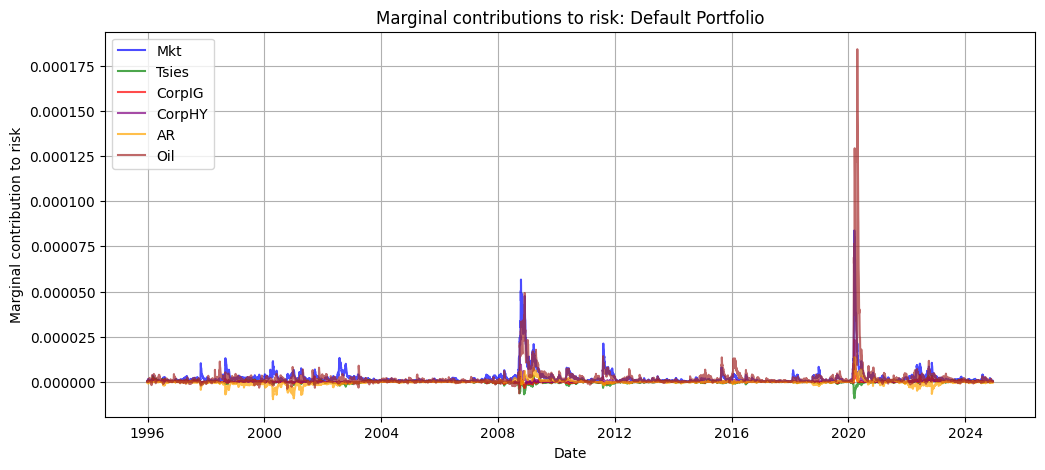

In [312]:
lambda_ = 0.94
window = 252

w_default = np.array([0.50, 0.30, 0.05, 0.00, 0.10, 0.05])
w_augmented_no_oil = np.array([0.40, 0.40, 0.00, 0.05, 0.15])

# --- Default Portfolio (with oil) ---
marginal_contrib_default_all = []

for i in range(window, len(df)):
    returns_window = returns.iloc[i - window:i]
    exp_weights = (lambda_ ** np.arange(window - 1, -1, -1))[:, np.newaxis]
    weighted_returns = returns_window * exp_weights
    cov_matrix_window = weighted_returns.cov()
    marginal_contrib_default = np.dot(cov_matrix_window, w_default)
    marginal_contrib_default_all.append(marginal_contrib_default)

marginal_contrib_default_df = pd.DataFrame(marginal_contrib_default_all,
                                            columns=df.columns[0:len(w_default)],
                                            index=df.index[window:])


# Default Portfolio Plot
plt.figure(figsize=(12, 5))
for i, col in enumerate(marginal_contrib_default_df.columns):
    plt.plot(marginal_contrib_default_df.index, marginal_contrib_default_df[col],
                 label=f'{col}', alpha=0.7, color=colors1[i])

plt.xlabel('Date')
plt.ylabel('Marginal contribution to risk')
plt.title('Marginal contributions to risk: Default Portfolio')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()


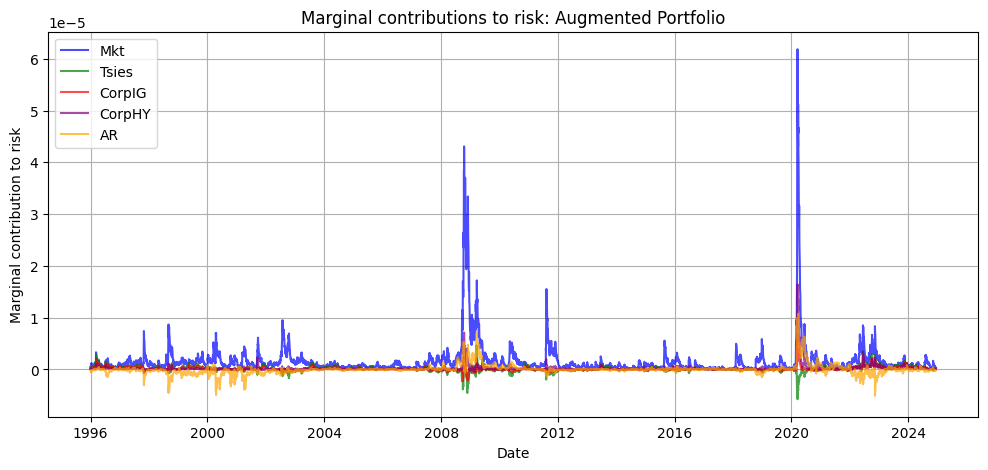

In [313]:
# --- Augmented Portfolio (without oil) ---
marginal_contrib_augmented_no_oil_all = []

for i in range(window, len(df)):
    returns_window = returns.iloc[i - window:i]
    exp_weights = (lambda_ ** np.arange(window - 1, -1, -1))[:, np.newaxis]
    weighted_returns = returns_window * exp_weights
    cov_matrix_window = weighted_returns.cov()

    # Select relevant part of covariance matrix (excluding Oil)
    cov_matrix_window_no_oil = cov_matrix_window.iloc[:5, :5]
    marginal_contrib_augmented_no_oil = np.dot(cov_matrix_window_no_oil, w_augmented_no_oil)
    marginal_contrib_augmented_no_oil_all.append(marginal_contrib_augmented_no_oil)

marginal_contrib_augmented_no_oil_df = pd.DataFrame(marginal_contrib_augmented_no_oil_all,
                                                     columns=df.columns[0:len(w_augmented_no_oil)],
                                                     index=df.index[window:])

# Augmented Portfolio Plot
plt.figure(figsize=(12, 5))
for i, col in enumerate(marginal_contrib_augmented_no_oil_df.columns):
    plt.plot(marginal_contrib_augmented_no_oil_df.index, marginal_contrib_augmented_no_oil_df[col],
                 label=f'{col}', alpha=0.7, color=colors[i])

plt.xlabel('Date')
plt.ylabel('Marginal contribution to risk')
plt.title('Marginal contributions to risk: Augmented Portfolio')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

- But way less visual than with classic 252 rolling window

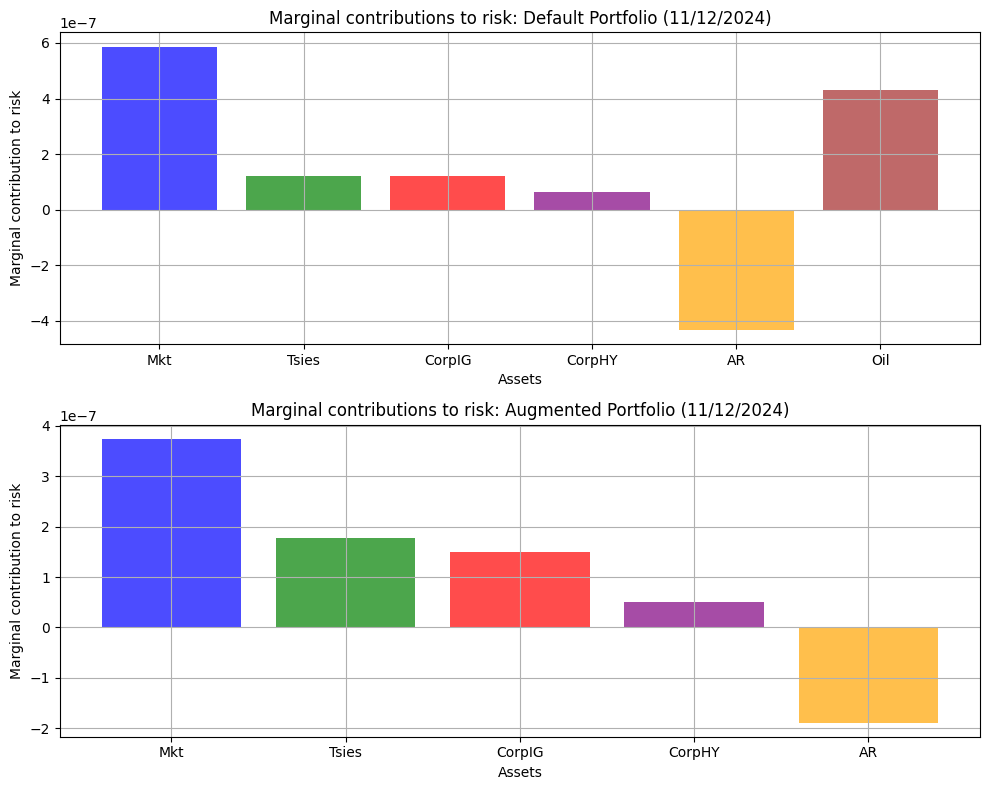

In [314]:
# And only for 2024-12-11
date_target = pd.to_datetime('2024-12-11')
marginal_contrib_default_11dec = marginal_contrib_default_df.loc[date_target]
marginal_contrib_augmented_11dec = marginal_contrib_augmented_no_oil_df.loc[date_target]

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
axes[0].bar(marginal_contrib_default_11dec.index, marginal_contrib_default_11dec,
            color=colors1[:len(marginal_contrib_default_11dec)], alpha=0.7)
axes[0].set_xlabel('Assets')
axes[0].set_ylabel('Marginal contribution to risk')
axes[0].set_title('Marginal contributions to risk: Default Portfolio (11/12/2024)')
axes[0].grid(True)

axes[1].bar(marginal_contrib_augmented_11dec.index, marginal_contrib_augmented_11dec,
            color=colors1[:len(marginal_contrib_augmented_11dec)], alpha=0.7)
axes[1].set_xlabel('Assets')
axes[1].set_ylabel('Marginal contribution to risk')
axes[1].set_title('Marginal contributions to risk: Augmented Portfolio (11/12/2024)')
axes[1].grid(True)

plt.tight_layout()
plt.show()
